In [1]:
from helium import start_chrome, click, wait_until, scroll_down
from selenium.webdriver.common.action_chains import ActionChains
import time
import pandas as pd
from bs4 import BeautifulSoup
from io import StringIO
from selenium import webdriver
from selenium.webdriver.common.by import By
import random

In [77]:
import warnings
warnings.filterwarnings('ignore')


In [24]:
pd.reset_option('all')

C:\Users\Caden\AppData\Local\Temp\ipykernel_10400\2786130087.py:1: FutureWarning: data_manager option is deprecated and will be removed in a future version. Only the BlockManager will be available.
  pd.reset_option('all')
C:\Users\Caden\AppData\Local\Temp\ipykernel_10400\2786130087.py:1: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  pd.reset_option('all')


In [39]:
pd.set_option('display.max_rows', None)

In [89]:
pd.set_option('display.max_columns', None)

In [ ]:
urls = [
    "https://goduke.com/sports/mens-lacrosse/stats/",
    "https://goheels.com/sports/mlax/stats/",
    "https://cuse.com/sports/mens-lacrosse/stats/",
    "https://goduke.com/sports/womens-lacrosse/stats/",
    "https://bceagles.com/sports/womens-lacrosse/stats/",
    "https://gocards.com/sports/womens-lacrosse/stats/",
    "https://goheels.com/sports/womens-lacrosse/stats/",
    "https://cuse.com/sports/womens-lacrosse/stats/"
]
years = [2024, 2023, 2022, 2021, 2020, 2019, 2018, 2017, 2016]


In [32]:
years = [2024, 2023, 2022, 2021, 2020, 2019, 2018, 2017, 2016, 2015, 2014, 2013, 2012, 2011, 2010]

urls = [
    "https://bceagles.com/sports/womens-lacrosse/stats/"
]

# Initialize an empty DataFrame
laxstats = pd.DataFrame()

for year in years:
    for url in urls:
        driver = start_chrome(f"{url}{year}", headless=False)

    # Wait for 3 seconds
        time.sleep(3)

        scroll_down(300)
        time.sleep(7)

    # Click the "Individual" button
        click("Individual")

    # Wait for the table to load
        time.sleep(2)
    # Parse the page source with BeautifulSoup
        soup = BeautifulSoup(driver.page_source, "html.parser")

    # Find the table
        table = soup.find('table', class_="sidearm-table highlight-column-hover collapse-on-medium accordion")

    # Convert the table to a DataFrame and append to mlaxdf
        if table:
            html_content = StringIO(str(table))
            df = pd.read_html(html_content)[0]
            df['Year'] = year  # Add year column for reference
            df['Team'] = url
            laxstats = pd.concat([laxstats, df], ignore_index=True)
            print(f"Data for {year} and {url} added")
        else:
            print(f"Table not found for {year} and {url}")

        driver.quit()

Data for 2024 and https://bceagles.com/sports/womens-lacrosse/stats/ added
Data for 2023 and https://bceagles.com/sports/womens-lacrosse/stats/ added
Data for 2022 and https://bceagles.com/sports/womens-lacrosse/stats/ added
Data for 2021 and https://bceagles.com/sports/womens-lacrosse/stats/ added
Data for 2020 and https://bceagles.com/sports/womens-lacrosse/stats/ added
Data for 2019 and https://bceagles.com/sports/womens-lacrosse/stats/ added
Data for 2018 and https://bceagles.com/sports/womens-lacrosse/stats/ added
Data for 2017 and https://bceagles.com/sports/womens-lacrosse/stats/ added
Data for 2016 and https://bceagles.com/sports/womens-lacrosse/stats/ added
Data for 2015 and https://bceagles.com/sports/womens-lacrosse/stats/ added


LookupError: 

In [33]:
laxstats.to_csv("lax_stats.csv", index=False)

In [27]:
laxstats = pd.read_csv("lax_stats.csv")

In [34]:
laxstats['Name'] = laxstats['Player'].str.extract(r',\s*(.*?)\s*,')
laxstats = laxstats.drop(columns=['Player'])

In [35]:
laxstats = laxstats[~laxstats['#'].isin(['TM'])]  # Remove "TM" rows
laxstats = laxstats.dropna(subset=['#'])

In [36]:
# Split the 'GP-GS' column into two new columns
laxstats[['GP', 'GS']] = laxstats['GP-GS'].str.split('-', expand=True)

# Convert 'GP' and 'GS' columns to integers if needed
laxstats['GP'] = laxstats['GP'].astype(int)
laxstats['GS'] = laxstats['GS'].astype(int)

# Drop the original 'GP-GS' column if no longer needed
laxstats = laxstats.drop(columns=['GP-GS'])

In [37]:
# Split the 'GP-GS' column into two new columns
laxstats[['FOW', 'TFO']] = laxstats['FO'].str.split('-', expand=True)

laxstats = laxstats.drop(columns=['FO'])

KeyError: 'FO'

In [38]:
laxstats['team'] = laxstats['Team'] 

In [96]:
team_map = {
    'goduke': 'Duke',
    'goheels': 'UNC',
    'cuse': 'Syracuse',
    'bceagles': 'BC',
    'gocards': 'Louisville'
}

# Function to check URL and assign the corresponding team
def get_team(url):
    for keyword, team in team_map.items():
        if keyword in url:
            return team
    return None  # Default if no match is found


In [39]:
# Apply function to create new column
laxstats['Team'] = laxstats['team'].apply(get_team)

In [97]:
gender_map = {
    'womens': 'Womens'
}

# Function to check URL and assign the corresponding team
def get_gender(url):
    for keyword, gender in gender_map.items():
        if keyword in url:
            return gender
        else:
            return "Mens"
    return None  

In [40]:
# Apply function to create new column
laxstats['Gender'] = laxstats['team'].apply(get_gender)

In [41]:
laxstats = laxstats[['Name', '#', 'Gender', 'Team', 'Year', 'GP', 'GS', 'G', 'A', 'PTS', 'SH', 'SH%', 'SOG', 'SOG%', 'GWG', 'UP', 'DWN', 'GB', 'TO', 'CT', 'FO%', 'FPG', 'FPS', 'DC', 'FOW', 'TFO']]

KeyError: "['UP', 'DWN', 'FO%', 'FOW', 'TFO'] not in index"

In [42]:
laxstats_max_gp = laxstats.groupby(['Team', 'Year', 'Gender'])['GP'].max().reset_index()

In [43]:
laxstats = laxstats.merge(laxstats_max_gp, on=['Team', 'Year', 'Gender'], suffixes=('', '_max'))

In [44]:
laxstats['GP%'] = round((laxstats['GP']/laxstats['GP_max']) * 100, 2)

In [45]:
laxstats

,#,G,A,PTS,SH,SH%,SOG,SOG%,GWG,FPG,...,Bio Link,Year,Team,Name,GP,GS,team,Gender,GP_max,GP%
0,1,78,23,101,142,0.549,105,0.739,5,11,...,View Bio,2024,BC,Rachel Clark,22,22,https://bceagles.com/sports/womens-lacrosse/st...,Womens,23,95.65
1,3,26,69,95,70,0.371,49,0.700,2,1,...,View Bio,2024,BC,Mckenna Davis,23,23,https://bceagles.com/sports/womens-lacrosse/st...,Womens,23,100.00
2,13,58,28,86,108,0.537,85,0.787,4,5,...,View Bio,2024,BC,Emma LoPinto,23,1,https://bceagles.com/sports/womens-lacrosse/st...,Womens,23,100.00
3,38,68,8,76,132,0.515,94,0.712,1,10,...,View Bio,2024,BC,Kayla Martello,23,23,https://bceagles.com/sports/womens-lacrosse/st...,Womens,23,100.00
4,5,43,20,63,79,0.544,60,0.759,2,6,...,View Bio,2024,BC,Belle Smith,23,23,https://bceagles.com/sports/womens-lacrosse/st...,Womens,23,100.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
281,32,0,0,0,0,0.000,0,0.000,0,0,...,View Bio,2015,BC,Zoe Ochoa,19,19,https://bceagles.com/sports/womens-lacrosse/st...,Womens,19,100.00
282,30,0,0,0,0,0.000,0,0.000,0,0,...,View Bio,2015,BC,Lindsey Reder,3,0,https://bceagles.com/sports/womens-lacrosse/st...,Womens,19,15.79
283,2,0,0,0,1,0.000,0,0.000,0,0,...,View Bio,2015,BC,Stephanie Sabatini,19,19,https://bceagles.com/sports/womens-lacrosse/st...,Womens,19,100.00
284,15,0,0,0,0,0.000,0,0.000,0,0,...,View Bio,2015,BC,Madeline Soutter,3,0,https://bceagles.com/sports/womens-lacrosse/st...,Womens,19,15.79


In [15]:
unc2021 = laxstats

In [51]:
combined_data = pd.concat([laxstats, combined_data], ignore_index=True)


In [50]:
laxstats = pd.read_excel("lax_stats_injuries.xlsx")

In [57]:
combined_data.to_excel("lax_stats_updated_injuries.xlsx", index=False)

In [55]:
combined_data = combined_data.sort_values(by=["Team", "Gender", "Name", "Year"], ascending=True)

In [41]:
combined_data = pd.read_excel("lax_stats_updated_injuries.xlsx")

In [42]:
womens_only_data = combined_data[combined_data['Gender'] == 'Womens']

In [45]:
filtered_data.to_excel("lax_stats_updated_injuries.xlsx", index=False)

In [44]:
name_counts = womens_only_data['Name'].value_counts()
name_counts
filtered_data = womens_only_data[womens_only_data['Name'].isin(name_counts[name_counts > 3].index)]
filtered_data

,Name,#,Gender,Team,Year,GP,GS,Injury,HS Injury,G,...,TO,CT,FO%,FPG,FPS,DC,FOW,TFO,GP_max,GP%
2,Abbey Ngai,23,Womens,BC,2018,3,0,0.0,0.0,0,...,0,0,NaN,0,0,0,NaN,NaN,24,12.50
3,Abbey Ngai,23,Womens,BC,2019,21,18,0.0,0.0,0,...,8,2,NaN,0,0,0,NaN,NaN,24,87.50
4,Abbey Ngai,23,Womens,BC,2020,1,0,0.0,0.0,0,...,0,0,NaN,0,0,0,NaN,NaN,7,14.29
5,Abbey Ngai,23,Womens,BC,2021,8,0,0.0,0.0,0,...,1,1,NaN,0,0,0,NaN,NaN,21,38.10
14,Andrea Reynolds,16,Womens,BC,2021,14,0,0.0,0.0,2,...,7,1,NaN,0,1,1,NaN,NaN,21,66.67
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1340,Taylor Moreno,30,Womens,UNC,2018,16,8,NaN,NaN,0,...,2,6,NaN,0,0,0,NaN,NaN,21,76.19
1341,Taylor Moreno,30,Womens,UNC,2019,21,21,NaN,NaN,0,...,7,3,NaN,0,0,1,NaN,NaN,21,100.00
1342,Taylor Moreno,30,Womens,UNC,2020,7,7,NaN,NaN,0,...,0,1,NaN,0,0,0,NaN,NaN,7,100.00
1343,Taylor Moreno,30,Womens,UNC,2021,21,21,NaN,NaN,0,...,3,6,NaN,0,0,0,NaN,NaN,21,100.00


In [55]:
urls = [
    "https://goduke.com/sports/womens-lacrosse/roster/",
    "https://bceagles.com/sports/womens-lacrosse/roster/",
    "https://gocards.com/sports/womens-lacrosse/roster/",
    "https://goheels.com/sports/womens-lacrosse/roster/",
    "https://cuse.com/sports/womens-lacrosse/roster/"
]
years = [2024, 2023, 2022, 2021, 2020, 2019, 2018, 2017, 2016]


In [61]:
urls = [
    "https://goduke.com/sports/mens-lacrosse/roster/",
    "https://goheels.com/sports/mlax/roster/",
    "https://cuse.com/sports/mens-lacrosse/roster/"
]
years = [2024, 2023, 2022, 2021, 2020, 2019, 2018, 2017, 2016]


In [62]:
# Initialize an empty DataFrame
laxrosters = pd.DataFrame()

for year in years:
    for url in urls:
        
        # Handle special case for Syracuse Women's Lacrosse 2020-21
        if url == "https://cuse.com/sports/womens-lacrosse/roster/" and year == 2020:
            formatted_url = f"{url}{year}-21"
        else:
            formatted_url = f"{url}{year}"
            
        driver = start_chrome(formatted_url, headless=False)  # Use formatted_url here!
        time.sleep(random.uniform(5, 10))
        scroll_down(100)
        time.sleep(random.uniform(5, 10))
        
        try:
            button = driver.find_element(By.ID, "_viewType_table")

            # Click the button
            button.click()
            time.sleep(random.uniform(5, 10))

            for _ in range(9):
                scroll_down(500)
                time.sleep(random.uniform(5, 10))

            soup = BeautifulSoup(driver.page_source, "html.parser")
            table = soup.find('table', class_="w-full")

            if table:
                html_content = StringIO(str(table))
                df = pd.read_html(html_content)[0]
                df['Year'] = year  # Add year column for reference
                df['Team'] = url
                laxrosters = pd.concat([laxrosters, df], ignore_index=True)
                print(f"Data for {year} and {formatted_url} added")
            else:
                print(f"Table not found for {year} and {formatted_url}")
        
        except Exception as e:
            print(f"Error processing {formatted_url}: {e}")

        driver.quit()


Data for 2024 and https://goduke.com/sports/mens-lacrosse/roster/2024 added
Data for 2024 and https://goheels.com/sports/mlax/roster/2024 added
Data for 2024 and https://cuse.com/sports/mens-lacrosse/roster/2024 added
Data for 2023 and https://goduke.com/sports/mens-lacrosse/roster/2023 added
Data for 2023 and https://goheels.com/sports/mlax/roster/2023 added
Data for 2023 and https://cuse.com/sports/mens-lacrosse/roster/2023 added
Data for 2022 and https://goduke.com/sports/mens-lacrosse/roster/2022 added
Data for 2022 and https://goheels.com/sports/mlax/roster/2022 added
Data for 2022 and https://cuse.com/sports/mens-lacrosse/roster/2022 added
Data for 2021 and https://goduke.com/sports/mens-lacrosse/roster/2021 added
Data for 2021 and https://goheels.com/sports/mlax/roster/2021 added
Data for 2021 and https://cuse.com/sports/mens-lacrosse/roster/2021 added
Data for 2020 and https://goduke.com/sports/mens-lacrosse/roster/2020 added
Data for 2020 and https://goheels.com/sports/mlax/ro

In [5]:
laxrosters.to_csv("lax_rosters.csv", index=False)

In [63]:
laxrosters

,No.,Name,Pos.,Ht.,Wt.,Yr.,Hometown / High School,Previous School,Year,Team,Cl.,Hometown / Previous School,Hometown / High School / Prev. School,#,Class,Pos,Hometown
0,0,Griffen Rakower,G,6' 1'',190,Gr.,"Pleasantville, N.Y. / Bryram Hills",Princeton,2024,https://goduke.com/sports/mens-lacrosse/roster/,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,Charles Balsamo,M,5' 8'',180,So.,"Manhasset, N.Y. / Chaminade",NaN,2024,https://goduke.com/sports/mens-lacrosse/roster/,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,Andrew McAdorey,M,5' 8'',190,Jr.,"Manorville, N.Y. / St. Anthony's",NaN,2024,https://goduke.com/sports/mens-lacrosse/roster/,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,Cameron Henry,D,6' 3'',205,Gr.,"Marietta, Ga. / McCallie School",NaN,2024,https://goduke.com/sports/mens-lacrosse/roster/,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,Mike Swirbalus,M,5' 10'',180,Gr.,"Westwood, Mass. / St. Sebastian's School",NaN,2024,https://goduke.com/sports/mens-lacrosse/roster/,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1380,81,Laz Chavez,D,5' 11'',211,RF,"Rye, N.Y. / Rye",NaN,2016,https://cuse.com/sports/mens-lacrosse/roster/,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1381,83,Andrew Helmer,LSM,6' 1'',187,Fr.,"Summit, N.J. / Summit",NaN,2016,https://cuse.com/sports/mens-lacrosse/roster/,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1382,88,Jay McDermott,D,6' 2'',207,Sr.,"Duxbury, Mass. / Duxbury",NaN,2016,https://cuse.com/sports/mens-lacrosse/roster/,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1383,89,Josh Pulver,LSM,5' 10'',188,R-So.,"Manlius, N.Y. / Fayetteville-Manlius",NaN,2016,https://cuse.com/sports/mens-lacrosse/roster/,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [60]:
wlaxrosters = laxrosters

In [144]:
full_lax_rosters = pd.concat([laxrosters, wlaxrosters], ignore_index=True)

In [145]:
full_lax_rosters = full_lax_rosters.drop(columns=['Instagram', 'Image', 'Twitter'])

In [146]:
full_lax_rosters['Academic Year'] = (
    full_lax_rosters[['Academic Year', 'Yr.', 'Cl.', 'Class']]
    .bfill(axis=1)
    .iloc[:, 0]
    .infer_objects(copy=False)  # Ensures proper data type inference
)

C:\Users\Caden\AppData\Local\Temp\ipykernel_5820\872781618.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  full_lax_rosters[['Academic Year', 'Yr.', 'Cl.', 'Class']]


In [147]:
full_lax_rosters['Name'] = full_lax_rosters['Name'].fillna(full_lax_rosters['Full Name'])

In [148]:
full_lax_rosters['Pos.'] = full_lax_rosters['Pos.'].fillna(full_lax_rosters['Pos'])

In [149]:
full_lax_rosters = full_lax_rosters.drop(columns=['Yr.', 'Cl.', 'Class', 'Full Name', 'Pos'])

In [150]:
full_lax_rosters['team'] = full_lax_rosters['Team'].apply(get_team)

In [151]:
full_lax_rosters['Gender'] = full_lax_rosters['Team'].apply(get_gender)

In [152]:
full_lax_rosters['Team'] = full_lax_rosters['team'] 
full_lax_rosters = full_lax_rosters.drop(columns=['team'])

In [153]:
full_lax_rosters = full_lax_rosters.drop(columns=['#', 'No.', 'Hometown / High School',
                                                  'Hometown / Previous School', 'Hometown / High School / Prev. School',
                                                  'Elig.', 'Previous School', 'Hometown'])

In [155]:
full_lax_rosters = full_lax_rosters[full_lax_rosters.iloc[:, 0] != "Skip Ad"]

In [162]:
from unidecode import unidecode

full_lax_rosters.loc[:, 'Name'] = full_lax_rosters['Name'].apply(lambda x: unidecode(x) if isinstance(x, str) else x)

In [182]:
full_lax_rosters['Pos.'].unique()

array(['GK', 'M', 'D', 'FO', 'A', 'Draw', nan], dtype=object)

In [181]:
full_lax_rosters['Pos.'] = full_lax_rosters['Pos.'].replace(
    {'LSM/D': 'M',
     'DM': 'M',
     'LSM': 'M',
     'SSDM':'M',
     'ATT/MID': 'A',
     'Attacker/Goalkeeper': 'GK',
     'Defend/Midfield': 'D',
     'Attack/Midfield' : 'A',
     'Defender/Midfielder': 'D',
     'Attacker/Midfielder': 'A',
     'M/D' : 'M',
     'D/M' : 'D',
     'M/A' : 'M',
     'Dr/M' : 'Draw',
     'Dr/D' : 'Draw',  
     'Midfielder/Defender' : 'M',
     'A/DRAW': 'Draw',
     'D/Dr' : 'Draw',
     'M/Dr' : 'Draw',
     'Draw Specialist': 'Draw',
     'Defender': 'D',
     'Goalie' : 'GK',
     'Defense': 'D',
     'Midfield/Defense': 'M',
     'Midfield/Attack': 'M',
     'Midfield': 'M', 
     'Attackman': 'A',
     'Attacker': 'A',
     'Attack': 'A',
     'F/O': 'FO',
     'LSM/FO': 'FO',
     'G' : 'GK',
     'Attackman/Midfielder' : 'A',
     'A/M' : 'A',
     'Goalkeeper' : 'GK',
     'Faceoff' : 'FO',
     'Midfielder' : 'M',
     'Defenseman' : 'D',
     'Defensive Midfielder' : 'M',
     'M/FO' : 'FO',
     'Face-Off Midfielder' : 'FO',
     'm' : 'M'
    }
)

C:\Users\Caden\AppData\Local\Temp\ipykernel_5820\3591100827.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  full_lax_rosters['Pos.'] = full_lax_rosters['Pos.'].replace(


In [184]:
full_lax_rosters.to_csv("full_lax_rosters.csv", index=False)

In [2]:
full_lax_rosters = pd.read_csv("full_lax_rosters.csv")

In [3]:
full_lax_stats = pd.read_excel("lax_stats_updated_injuries.xlsx")

In [4]:
full_lax_rosters

,Name,Pos.,Ht.,Wt.,Year,Team,Academic Year,Gender
0,Rachel Clark,A,5' 9'',NaN,2024,BC,NaN,Womens
1,Mallory Hasselbeck,A,5' 9'',NaN,2024,BC,NaN,Womens
2,Mckenna Davis,A,5' 6'',NaN,2024,BC,NaN,Womens
3,Annabelle Hasselbeck,M,5' 6'',NaN,2024,BC,NaN,Womens
4,Belle Smith,M,5' 5'',NaN,2024,BC,NaN,Womens
...,...,...,...,...,...,...,...,...
3002,Maggie Auslander,D,NaN,NaN,2016,UNC,Jr.,Womens
3003,Stephanie Lobb,D,NaN,NaN,2016,UNC,Jr.,Womens
3004,Sophie McCoy,M,NaN,NaN,2016,UNC,Jr.,Womens
3005,Caylee Waters,GK,NaN,NaN,2016,UNC,Jr.,Womens


In [5]:
full_lax_stats

,Name,#,Gender,Team,Year,GP,GS,Injury,HS Injury,G,...,TO,CT,FO%,FPG,FPS,DC,FOW,TFO,GP_max,GP%
0,Abbey Ngai,23,Womens,BC,2018,3,0,0.0,0.0,0,...,0,0,NaN,0,0,0,NaN,NaN,24,12.50
1,Abbey Ngai,23,Womens,BC,2019,21,18,0.0,0.0,0,...,8,2,NaN,0,0,0,NaN,NaN,24,87.50
2,Abbey Ngai,23,Womens,BC,2020,1,0,0.0,0.0,0,...,0,0,NaN,0,0,0,NaN,NaN,7,14.29
3,Abbey Ngai,23,Womens,BC,2021,8,0,0.0,0.0,0,...,1,1,NaN,0,0,0,NaN,NaN,21,38.10
4,Andrea Reynolds,16,Womens,BC,2021,14,0,0.0,0.0,2,...,7,1,NaN,0,1,1,NaN,NaN,21,66.67
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
687,Taylor Moreno,30,Womens,UNC,2018,16,8,NaN,NaN,0,...,2,6,NaN,0,0,0,NaN,NaN,21,76.19
688,Taylor Moreno,30,Womens,UNC,2019,21,21,NaN,NaN,0,...,7,3,NaN,0,0,1,NaN,NaN,21,100.00
689,Taylor Moreno,30,Womens,UNC,2020,7,7,NaN,NaN,0,...,0,1,NaN,0,0,0,NaN,NaN,7,100.00
690,Taylor Moreno,30,Womens,UNC,2021,21,21,NaN,NaN,0,...,3,6,NaN,0,0,0,NaN,NaN,21,100.00


In [21]:
merged_df = pd.merge(full_lax_stats, full_lax_rosters, on=['Name', 'Year'], how='inner')
print(len(merged_df))  # Check if we get rows now


0


In [20]:
merged_df.to_csv("merged.csv", index=False)

In [26]:
full_lax_stats['Name'] = full_lax_stats['Name'].str.replace(r'\s{2,}', ' ', regex=True)

merged_df = pd.merge(full_lax_stats, full_lax_rosters, on=['Name', 'Year'], how='left')
print(len(merged_df))  # Should now return rows

692


In [11]:
print(full_lax_stats.duplicated(subset=['Name', 'Year']).sum())  # Should be 0
print(full_lax_rosters.duplicated(subset=['Name', 'Year']).sum())  # Should be 0


0
0


In [29]:
merged_df.to_csv('merged_df.csv')

In [91]:
merged_df = pd.read_excel("merged_df.xlsx")

In [92]:
merged_df

,Name,#,Pos.,Ht.,Gender,Team,Academic Year,Year,GP,GS,...,SOG%,GWG,GB,TO,CT,FPG,FPS,DC,GP_max,GP%
0,Abbey Ngai,23,GK,5' 7'',Womens,BC,Fr.,2018,3,0,...,0.0,0,2,0,0,0,0,0,24,12.50
1,Abbey Ngai,23,GK,5' 7'',Womens,BC,So.,2019,21,18,...,0.0,0,32,8,2,0,0,0,24,87.50
2,Abbey Ngai,23,GK,5' 7'',Womens,BC,Jr.,2020,1,0,...,0.0,0,0,0,0,0,0,0,7,14.29
3,Abbey Ngai,23,GK,5' 7'',Womens,BC,Sr.,2021,8,0,...,0.0,0,5,1,1,0,0,0,21,38.10
4,Andrea Reynolds,16,M,5' 7'',Womens,BC,Fr.,2021,14,0,...,0.4,0,1,7,1,0,1,1,21,66.67
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
692,Taylor Moreno,30,GK,5' 7'',Womens,UNC,R-Fr.,2018,16,8,...,0.0,0,31,2,6,0,0,0,21,76.19
693,Taylor Moreno,30,GK,5' 7'',Womens,UNC,So.,2019,21,21,...,0.0,0,22,7,3,0,0,1,21,100.00
694,Taylor Moreno,30,GK,5' 7'',Womens,UNC,Jr.,2020,7,7,...,0.0,0,8,0,1,0,0,0,7,100.00
695,Taylor Moreno,30,GK,5' 7'',Womens,UNC,Sr.,2021,21,21,...,0.0,0,22,3,6,0,0,0,21,100.00


In [93]:
merged_df = merged_df.drop(columns=['GP_max', 'GP%'])

In [94]:
laxstats_max_gp = merged_df.groupby(['Team', 'Year', 'Gender'])['GP'].max().reset_index()

In [95]:
merged_df = merged_df.merge(laxstats_max_gp, on=['Team', 'Year', 'Gender'], suffixes=('', '_max'))

In [96]:
merged_df['GP%'] = round((merged_df['GP']/merged_df['GP_max']) * 100, 2)

In [97]:
merged_df['Injured_last_year'] = merged_df.groupby('Name')['Injury'].shift(1)
merged_df['Total_injuries_to_date'] = merged_df.groupby('Name')['Injury'].cumsum() - merged_df['Injury']
merged_df['Ever_injured'] = (merged_df['Total_injuries_to_date'] > 0).astype(int)

In [98]:
import re

def height_to_inches(ht):
    match = re.match(r"(\d+)'[\s]*(\d+)?", ht)
    if match:
        feet = int(match.group(1))
        inches = int(match.group(2)) if match.group(2) else 0
        return feet * 12 + inches
    return None  # or np.nan if you're working with pandas

# Example
print(height_to_inches("5' 7\""))  # Output: 67

67


In [99]:
merged_df['Ht'] = merged_df['Ht.'].apply(height_to_inches)
merged_df = merged_df.drop(columns=['Ht.'])

# K-Means

In [100]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import seaborn as sns


In [101]:
merged_df.columns

Index(['Name', '#', 'Pos.', 'Gender', 'Team', 'Academic Year', 'Year', 'GP',
       'GS', 'Injury', 'HS Injury', 'G', 'A', 'PTS', 'SH', 'SH%', 'SOG',
       'SOG%', 'GWG', 'GB', 'TO', 'CT', 'FPG', 'FPS', 'DC', 'GP_max', 'GP%',
       'Injured_last_year', 'Total_injuries_to_date', 'Ever_injured', 'Ht'],
      dtype='object')

In [102]:
#Create feature list
clustering_features = ['Pos.', 'Ht', 'GP%', 'G', 'A', 'SH', 'SH%', 'TO', 'GB', 'CT', 'FPG', 'DC']

In [103]:
#Turn Pos into a dummy
clustering_df = merged_df[clustering_features].copy()

clustering_df = pd.get_dummies(clustering_df, columns=['Pos.'])

clustering_features_encoded = clustering_df.columns.tolist()

In [104]:
#Scale the features to work better for K-Means
scaler = StandardScaler()
X_scaled = scaler.fit_transform(clustering_df)
X_scaled_df = pd.DataFrame(X_scaled, columns=clustering_features_encoded)

In [105]:
#Increase the weight on Position
for col in X_scaled_df.columns:
    if col.startswith("Pos."):
        X_scaled_df[col] *= 2

In [106]:
#Create clusters and add them to the merged_df dataset
kmeans = KMeans(n_clusters=7, random_state=42)
merged_df['player_cluster'] = kmeans.fit_predict(X_scaled_df)

C:\Users\Caden\anaconda3\envs\sal384\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


In [79]:
#Use elbow method to find optimal number of clusters
inertia = []
k_range = range(1, 16)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled_df)
    inertia.append(kmeans.inertia_)

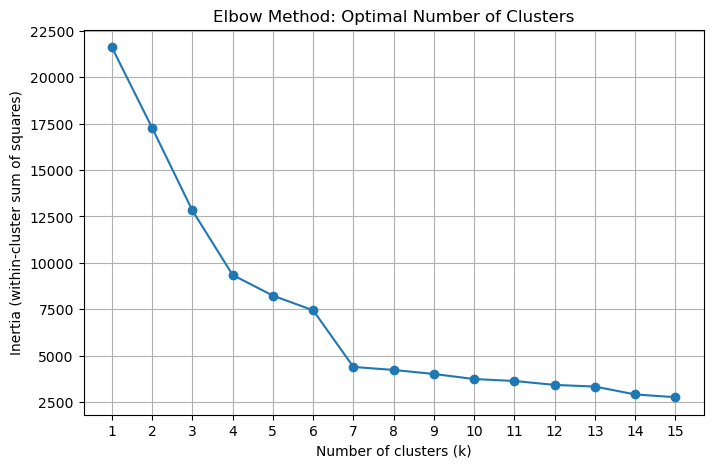

In [80]:
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o')
plt.title('Elbow Method: Optimal Number of Clusters')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia (within-cluster sum of squares)')
plt.xticks(k_range)
plt.grid(True)
plt.show()

In [107]:
merged_df['player_cluster'].value_counts().sort_index()

player_cluster
0    207
1    166
2     50
3    103
4     61
5     95
6     15
Name: count, dtype: int64

In [108]:
cluster_profiles = merged_df.groupby('player_cluster').mean(numeric_only = True)

In [109]:
cluster_profiles

,#,Year,GP,GS,Injury,HS Injury,G,A,PTS,SH,...,CT,FPG,FPS,DC,GP_max,GP%,Injured_last_year,Total_injuries_to_date,Ever_injured,Ht
player_cluster,,,,,,,,,,,,,,,,,,,,,
0,19.855072,2019.613527,11.043478,3.270531,0.077295,0.019324,3.381643,1.217391,4.599034,8.183575,...,3.086957,0.637681,1.685990,4.700483,17.159420,67.229662,0.068182,0.067633,0.062802,66.024155
1,22.096386,2020.795181,14.566265,11.000000,0.072289,0.012048,0.295181,0.277108,0.572289,0.867470,...,11.048193,0.072289,0.198795,7.897590,18.487952,78.807892,0.076389,0.192771,0.156627,66.475904
2,22.460000,2020.100000,11.120000,7.800000,0.040000,0.000000,0.000000,0.040000,0.040000,0.020000,...,2.400000,0.000000,0.020000,0.060000,18.040000,61.786200,0.051282,0.160000,0.160000,65.780000
3,18.660194,2020.572816,10.990291,4.029126,0.135922,0.087379,10.388350,4.776699,15.165049,21.834951,...,1.456311,1.533981,3.611650,5.601942,16.563107,69.412524,0.109589,0.155340,0.106796,66.776699
4,17.344262,2020.737705,20.459016,18.967213,0.016393,0.000000,53.934426,26.360656,80.295082,105.262295,...,6.606557,9.622951,18.836066,18.721311,20.918033,97.902951,0.107143,0.180328,0.163934,65.868852
5,19.115789,2020.831579,19.315789,14.600000,0.021053,0.031579,25.273684,8.715789,33.989474,56.273684,...,12.010526,5.842105,12.200000,28.010526,19.600000,98.652421,0.047619,0.126316,0.115789,66.494737
6,25.200000,2021.333333,12.666667,8.866667,0.133333,0.000000,4.066667,0.866667,4.933333,8.000000,...,0.866667,0.266667,0.666667,82.200000,19.933333,65.140000,0.153846,0.266667,0.266667,69.800000


In [88]:
merged_df.to_csv('merged_df.csv')

In [110]:
cluster_labels = {
    0: 'Bench Midfielder',
    1: 'Defender',
    2: 'Goalkeeper',
    3: 'Bench Attacker',
    4: 'Star Attacker',
    5: 'Star Midfielder',
    6: 'Draw Taker'
}

merged_df['cluster_label'] = merged_df['player_cluster'].map(cluster_labels)

In [111]:
pca = PCA(n_components=2)
pca_components = pca.fit_transform(X_scaled_df)

merged_df['PCA1'] = pca_components[:, 0]
merged_df['PCA2'] = pca_components[:, 1]

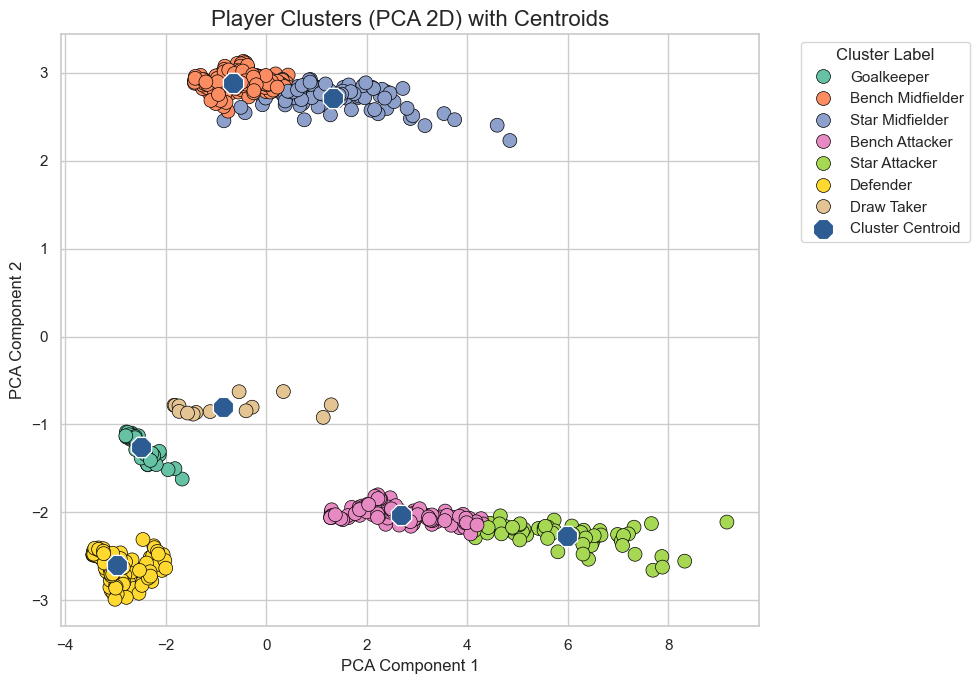

In [123]:
import matplotlib.pyplot as plt
import seaborn as sns

# First, calculate the centroids
centroids = merged_df.groupby('cluster_label')[['PCA1', 'PCA2']].mean().reset_index()

# Now plot
plt.figure(figsize=(10, 7))
sns.set(style='whitegrid')

# Scatter plot for players
sns.scatterplot(
    data=merged_df,
    x='PCA1',
    y='PCA2',
    hue='cluster_label',
    palette='Set2',
    s=100,
    edgecolor='black',
    linewidth=0.5
)

# Add centroid markers
plt.scatter(
    centroids['PCA1'],
    centroids['PCA2'],
    c='#2C5C92',            # black color for centroids
    marker='8',
    edgecolor='white',# 'X' marker
    s=250,                # bigger size
    label='Cluster Centroid'  # optional
)

plt.title('Player Clusters (PCA 2D) with Centroids', fontsize=16)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(title='Cluster Label', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


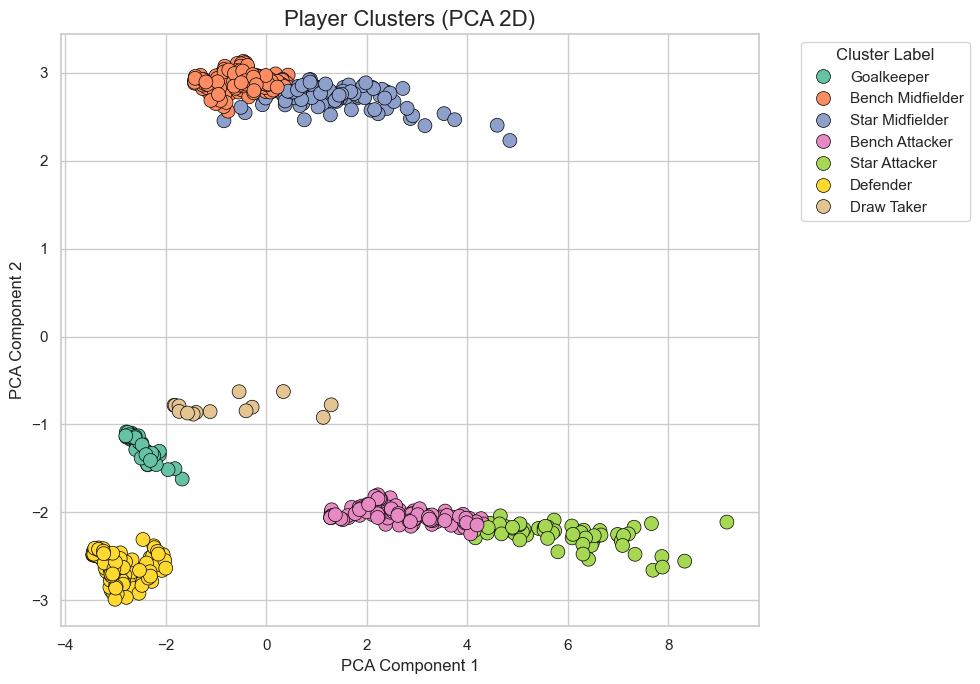

In [97]:
plt.figure(figsize=(10, 7))
sns.set(style='whitegrid')

sns.scatterplot(
    data=merged_df,
    x='PCA1',
    y='PCA2',
    hue='cluster_label',
    palette='Set2',
    s=100,
    edgecolor='black',
    linewidth=0.5
)

plt.title('Player Clusters (PCA 2D)', fontsize=16)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(title='Cluster Label', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


# Model

In [25]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [103]:
merged_df.columns

Index(['Name', '#', 'Pos.', 'Gender', 'Team', 'Academic Year', 'Year', 'GP',
       'GS', 'Injury', 'HS Injury', 'G', 'A', 'PTS', 'SH', 'SH%', 'SOG',
       'SOG%', 'GWG', 'GB', 'TO', 'CT', 'FPG', 'FPS', 'DC', 'GP_max', 'GP%',
       'Injured_last_year', 'Total_injuries_to_date', 'Ever_injured', 'Ht',
       'player_cluster', 'cluster_label', 'PCA1', 'PCA2'],
      dtype='object')

In [194]:
df = merged_df.copy()

# Filter out GP == 0 to avoid division by zero
df = df[df['GP'] > 0].copy()

# Calculate per-game stats
df['GPG'] = df['G'] / df['GP']
df['APG'] = df['A'] / df['GP']
df['PTSPG'] = df['PTS'] / df['GP']
df['SOGPG'] = df['SOG'] / df['GP']
df['GBPG'] = df['GB'] / df['GP']
df['TOPG'] = df['TO'] / df['GP']
df['CTPG'] = df['CT'] / df['GP']
df['FPGPG'] = df['FPG'] / df['GP']
df['FPSPG'] = df['FPS'] / df['GP']
df['DCPG'] = df['DC'] / df['GP']

In [195]:
field_players_df = df[~df['Pos.'].isin(['GK', 'Draw'])].copy()

In [196]:
df = field_players_df.sort_values(by=['Name', 'Year'])

target_stats = ['GPG', 'APG', 'PTSPG', 'SOGPG', 'GBPG', 'TOPG', 'CTPG', 'FPGPG', 'FPSPG']
for stat in target_stats:
    df[f'{stat}_next'] = df.groupby('Name')[stat].shift(-1)

df = df.dropna(subset=[f'{stat}_next' for stat in target_stats])


In [14]:
df = pd.read_csv("model_testing.csv").drop(columns=['Unnamed: 0'])

In [15]:
stats_to_lag = ['GPG', 'APG', 'PTSPG', 'SOGPG', 'GBPG', 'TOPG', 'CTPG', 'FPGPG', 'FPSPG']

df = df.sort_values(by=['Name', 'Year'])  # assuming 'Player' and 'Season' exist

# For each stat, create a lag column (prior season)
for stat in stats_to_lag:
    df[f'{stat}_last_season'] = df.groupby('Name')[stat].shift(1)

for stat in stats_to_lag:
    df[f'{stat}_last_season'] = df[f'{stat}_last_season'].fillna(0)

In [16]:
df.columns

Index(['Name', '#', 'Pos.', 'Gender', 'Team', 'Academic Year', 'Year', 'GP',
       'GS', 'Injury', 'HS Injury', 'G', 'A', 'PTS', 'SH', 'SH%', 'SOG',
       'SOG%', 'GWG', 'GB', 'TO', 'CT', 'FPG', 'FPS', 'DC', 'GP_max', 'GP%',
       'Injured_last_year', 'Total_injuries_to_date', 'Ever_injured', 'Ht',
       'player_cluster', 'cluster_label', 'PCA1', 'PCA2', 'GPG', 'APG',
       'PTSPG', 'SOGPG', 'GBPG', 'TOPG', 'CTPG', 'FPGPG', 'FPSPG', 'DCPG',
       'GPG_next', 'APG_next', 'PTSPG_next', 'SOGPG_next', 'GBPG_next',
       'TOPG_next', 'CTPG_next', 'FPGPG_next', 'FPSPG_next', 'DCPG_next',
       'GPG_last_season', 'APG_last_season', 'PTSPG_last_season',
       'SOGPG_last_season', 'GBPG_last_season', 'TOPG_last_season',
       'CTPG_last_season', 'FPGPG_last_season', 'FPSPG_last_season'],
      dtype='object')

In [18]:
df_model = df

In [19]:
df_model.columns

Index(['Name', '#', 'Pos.', 'Gender', 'Team', 'Academic Year', 'Year', 'GP',
       'GS', 'Injury', 'HS Injury', 'G', 'A', 'PTS', 'SH', 'SH%', 'SOG',
       'SOG%', 'GWG', 'GB', 'TO', 'CT', 'FPG', 'FPS', 'DC', 'GP_max', 'GP%',
       'Injured_last_year', 'Total_injuries_to_date', 'Ever_injured', 'Ht',
       'player_cluster', 'cluster_label', 'PCA1', 'PCA2', 'GPG', 'APG',
       'PTSPG', 'SOGPG', 'GBPG', 'TOPG', 'CTPG', 'FPGPG', 'FPSPG', 'DCPG',
       'GPG_next', 'APG_next', 'PTSPG_next', 'SOGPG_next', 'GBPG_next',
       'TOPG_next', 'CTPG_next', 'FPGPG_next', 'FPSPG_next', 'DCPG_next',
       'GPG_last_season', 'APG_last_season', 'PTSPG_last_season',
       'SOGPG_last_season', 'GBPG_last_season', 'TOPG_last_season',
       'CTPG_last_season', 'FPGPG_last_season', 'FPSPG_last_season'],
      dtype='object')

In [20]:
# Step 1: Get list of players who have ever been injured
injured_players = df_model[df_model['Injury'] == 1]['Name'].unique()

# Step 2: Filter out all rows belonging to those players
df_train = df_model[~df_model['Name'].isin(injured_players)].copy()

# Confirm how many rows and players are left
print("Original dataset:", df_model.shape[0], "rows")
print("Filtered (injury-free careers only):", df_train.shape[0], "rows")
print("Unique players after filtering:", df_train['Name'].nunique())


Original dataset: 472 rows
Filtered (injury-free careers only): 385 rows
Unique players after filtering: 118


In [21]:
print(df_train['Academic Year'].unique())

['Fr.' 'So.' 'Jr.' 'Sr.' 'RF' 'R-So.' 'R-Jr.' 'R-Sr.']


In [22]:
# One-hot encode Academic Year
df_train = pd.get_dummies(df_train, columns=['Academic Year'])

In [23]:
df_train.columns

Index(['Name', '#', 'Pos.', 'Gender', 'Team', 'Year', 'GP', 'GS', 'Injury',
       'HS Injury', 'G', 'A', 'PTS', 'SH', 'SH%', 'SOG', 'SOG%', 'GWG', 'GB',
       'TO', 'CT', 'FPG', 'FPS', 'DC', 'GP_max', 'GP%', 'Injured_last_year',
       'Total_injuries_to_date', 'Ever_injured', 'Ht', 'player_cluster',
       'cluster_label', 'PCA1', 'PCA2', 'GPG', 'APG', 'PTSPG', 'SOGPG', 'GBPG',
       'TOPG', 'CTPG', 'FPGPG', 'FPSPG', 'DCPG', 'GPG_next', 'APG_next',
       'PTSPG_next', 'SOGPG_next', 'GBPG_next', 'TOPG_next', 'CTPG_next',
       'FPGPG_next', 'FPSPG_next', 'DCPG_next', 'GPG_last_season',
       'APG_last_season', 'PTSPG_last_season', 'SOGPG_last_season',
       'GBPG_last_season', 'TOPG_last_season', 'CTPG_last_season',
       'FPGPG_last_season', 'FPSPG_last_season', 'Academic Year_Fr.',
       'Academic Year_Jr.', 'Academic Year_R-Jr.', 'Academic Year_R-So.',
       'Academic Year_R-Sr.', 'Academic Year_RF', 'Academic Year_So.',
       'Academic Year_Sr.'],
      dtype='object')

In [26]:
# Define input and target columns
input_columns = [
    'GPG', 'APG', 'SOGPG', 'GBPG', 'TOPG', 'CTPG',
    'GP%', 'player_cluster', 'GPG_last_season', 'APG_last_season',
    'SOGPG_last_season', 'GBPG_last_season',
    'TOPG_last_season', 'CTPG_last_season'
] + [col for col in df_model.columns if col.startswith("Academic Year_")]

target_columns = [
    'GPG_next', 'APG_next', 'SOGPG_next',
    'GBPG_next', 'TOPG_next', 'CTPG_next'
]

# Select only the columns you need
X = df_model[input_columns]
Y = df_model[target_columns]

# Split data
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Confirm shapes
print("X_train shape:", X_train.shape)
print("Y_train shape:", Y_train.shape)


X_train shape: (377, 14)
Y_train shape: (377, 6)


In [27]:
from xgboost import XGBRegressor
from sklearn.multioutput import MultiOutputRegressor

# Define your model
base_model = XGBRegressor(n_estimators=228, learning_rate=0.0131, max_depth=3, random_state=42)
model = MultiOutputRegressor(base_model)

# Retrain using updated X_train and Y_train
model.fit(X_train, Y_train)


MultiOutputRegressor(estimator=XGBRegressor(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric=None,
                                            feature_types=None,
                                            feature_weights=None, gamma=None,
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_constraints=None,
                                            learning_rate=0.0131, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=3,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=228, n_jobs=None,
                                            num_parallel_tree=None, ...))

In [124]:
from sklearn.metrics import mean_squared_error, r2_score

# Predict on test data
Y_pred = model.predict(X_test)

# Evaluate each stat
for i, col in enumerate(Y.columns):
    rmse = mean_squared_error(Y_test.iloc[:, i], Y_pred[:, i])
    r2 = r2_score(Y_test.iloc[:, i], Y_pred[:, i])
    print(f"{col} - RMSE: {rmse:.3f}, R²: {r2:.3f}")



GPG_next - RMSE: 0.314, R²: 0.761
APG_next - RMSE: 0.107, R²: 0.524
SOGPG_next - RMSE: 0.659, R²: 0.751
GBPG_next - RMSE: 0.138, R²: 0.524
TOPG_next - RMSE: 0.143, R²: 0.570
CTPG_next - RMSE: 0.109, R²: 0.514


In [126]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np  # you need numpy for sqrt

# Predict on test data
Y_pred = model.predict(X_test)

# Evaluate each stat
for i, col in enumerate(Y.columns):
    mse = mean_squared_error(Y_test.iloc[:, i], Y_pred[:, i])
    rmse = np.sqrt(mse)  # take the square root
    r2 = r2_score(Y_test.iloc[:, i], Y_pred[:, i])
    print(f"{col} - RMSE: {rmse:.3f}, R²: {r2:.3f}")


GPG_next - RMSE: 0.561, R²: 0.761
APG_next - RMSE: 0.328, R²: 0.524
SOGPG_next - RMSE: 0.812, R²: 0.751
GBPG_next - RMSE: 0.372, R²: 0.524
TOPG_next - RMSE: 0.379, R²: 0.570
CTPG_next - RMSE: 0.330, R²: 0.514


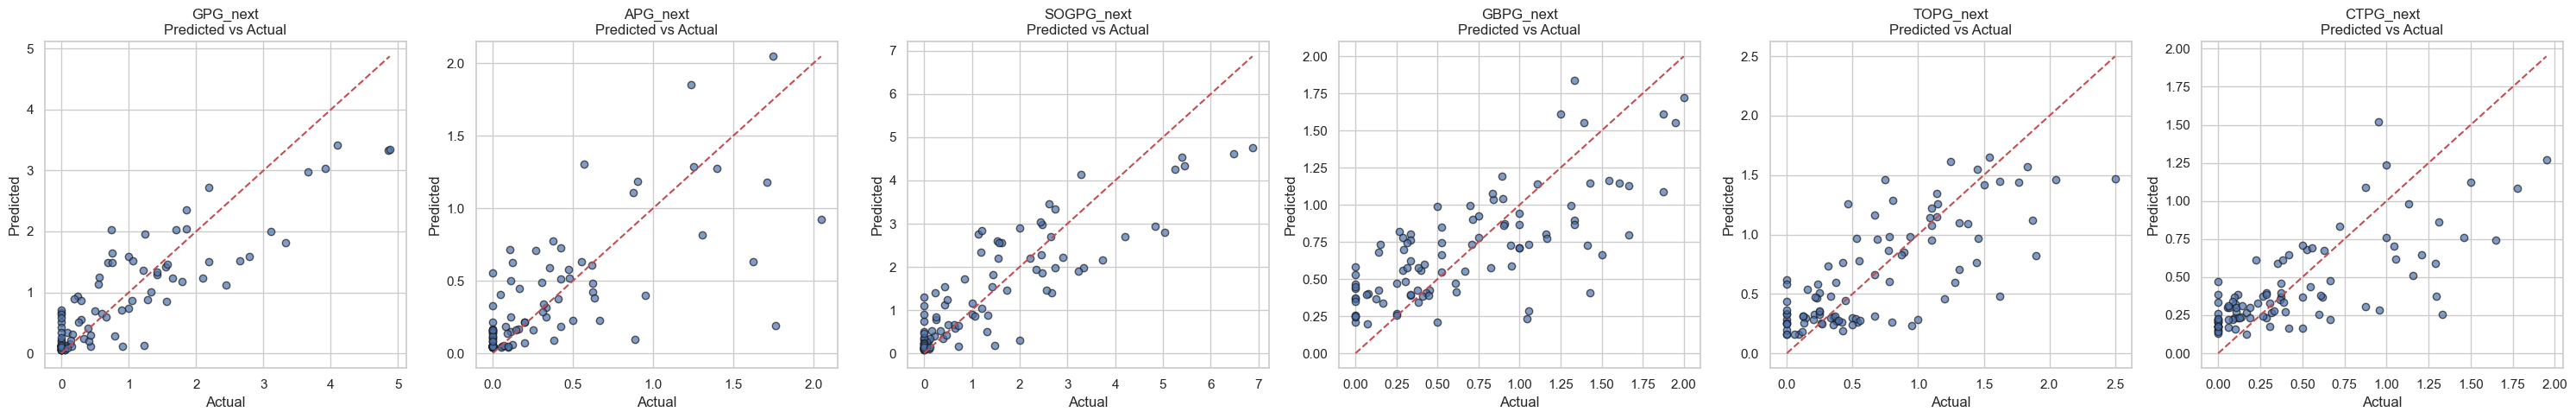

In [125]:
import matplotlib.pyplot as plt
import numpy as np

# Number of target variables
n_targets = Y.shape[1]

# Set up subplots
fig, axes = plt.subplots(1, n_targets, figsize=(5 * n_targets, 5))

# If only 1 target, axes might not be an array
if n_targets == 1:
    axes = [axes]

# Plot for each stat
for i, col in enumerate(Y.columns):
    ax = axes[i]
    
    ax.scatter(Y_test.iloc[:, i], Y_pred[:, i], alpha=0.7, edgecolor='k')
    ax.plot([Y_test.iloc[:, i].min(), Y_test.iloc[:, i].max()],
             [Y_test.iloc[:, i].min(), Y_test.iloc[:, i].max()],
             'r--')  # red dashed line for perfect prediction
    
    ax.set_title(f'{col}\nPredicted vs Actual')
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')

plt.tight_layout()
plt.show()


Parameter Tuning

In [229]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.multioutput import MultiOutputRegressor
from xgboost import XGBRegressor
from scipy.stats import uniform, randint
import numpy as np


In [230]:
param_dist = {
    'estimator__n_estimators': randint(100, 400),
    'estimator__learning_rate': uniform(0.01, 0.2),  # range: 0.01 to 0.21
    'estimator__max_depth': randint(3, 6),           # 3 to 5
    'estimator__subsample': uniform(0.6, 0.4),        # 0.6 to 1.0
    'estimator__colsample_bytree': uniform(0.6, 0.4)  # 0.6 to 1.0
}


In [231]:
base_model = XGBRegressor(random_state=42, tree_method='hist')  # hist speeds things up
multi_model = MultiOutputRegressor(base_model)

random_search = RandomizedSearchCV(
    estimator=multi_model,
    param_distributions=param_dist,
    n_iter=25,                 # number of random combinations to try
    scoring='r2',              # you could also use 'neg_mean_squared_error'
    cv=3,                      # 3-fold cross-validation
    verbose=2,
    n_jobs=-1,
    random_state=42
)


In [232]:
random_search.fit(X_train, Y_train)


Fitting 3 folds for each of 25 candidates, totalling 75 fits


RandomizedSearchCV(cv=3,
                   estimator=MultiOutputRegressor(estimator=XGBRegressor(base_score=None,
                                                                         booster=None,
                                                                         callbacks=None,
                                                                         colsample_bylevel=None,
                                                                         colsample_bynode=None,
                                                                         colsample_bytree=None,
                                                                         device=None,
                                                                         early_stopping_rounds=None,
                                                                         enable_categorical=False,
                                                                         eval_metric=None,
                                                                         feature_types=None,
                                                                         feature_weights=None,
                                                                         gamma=None,
                                                                         grow_policy=None,
                                                                         importance_t...
                                        'estimator__max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x000001BF325AA260>,
                                        'estimator__n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x000001BF325A9000>,
                                        'estimator__subsample': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x000001BF325785B0>},
                   random_state=42, scoring='r2', verbose=2)

In [233]:
print("Best parameters found:\n", random_search.best_params_)
print("Best R² score from CV:\n", random_search.best_score_)

# Use the best model
best_model = random_search.best_estimator_

# Predict and evaluate
Y_pred = best_model.predict(X_test)


Best parameters found:
 {'estimator__colsample_bytree': 0.6661067756252009, 'estimator__learning_rate': 0.013127281348238786, 'estimator__max_depth': 3, 'estimator__n_estimators': 228, 'estimator__subsample': 0.679486272613669}
Best R² score from CV:
 0.5928695201873779


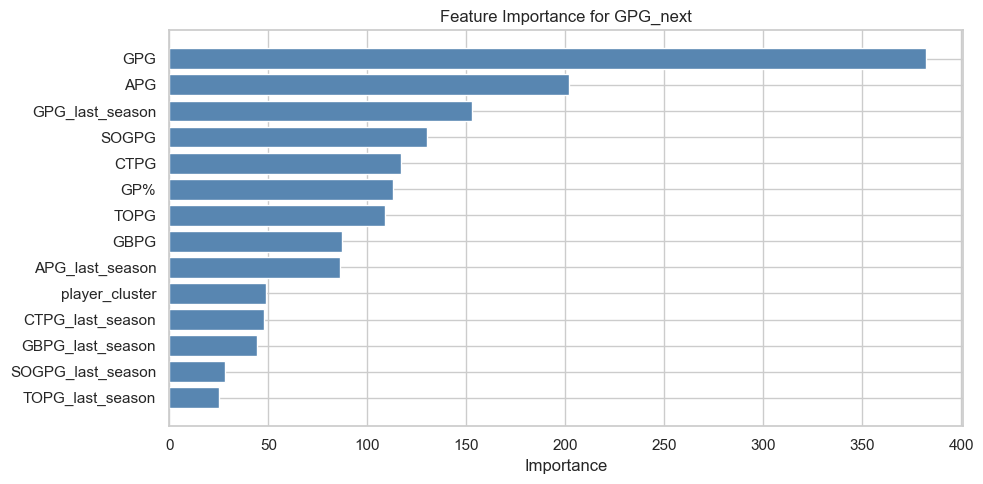

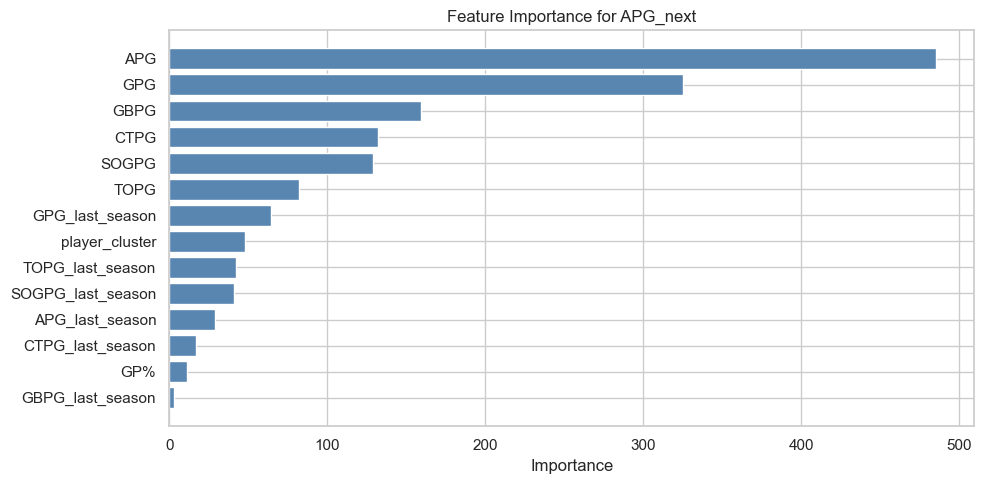

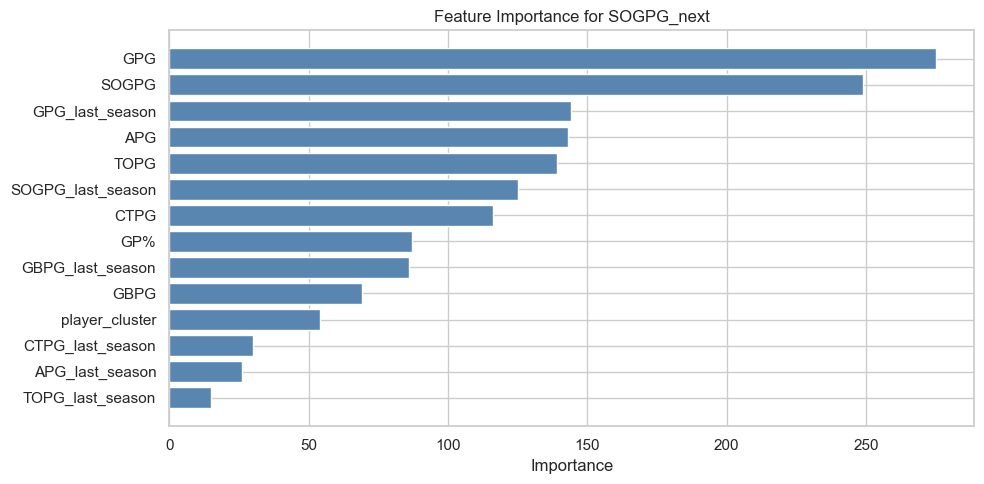

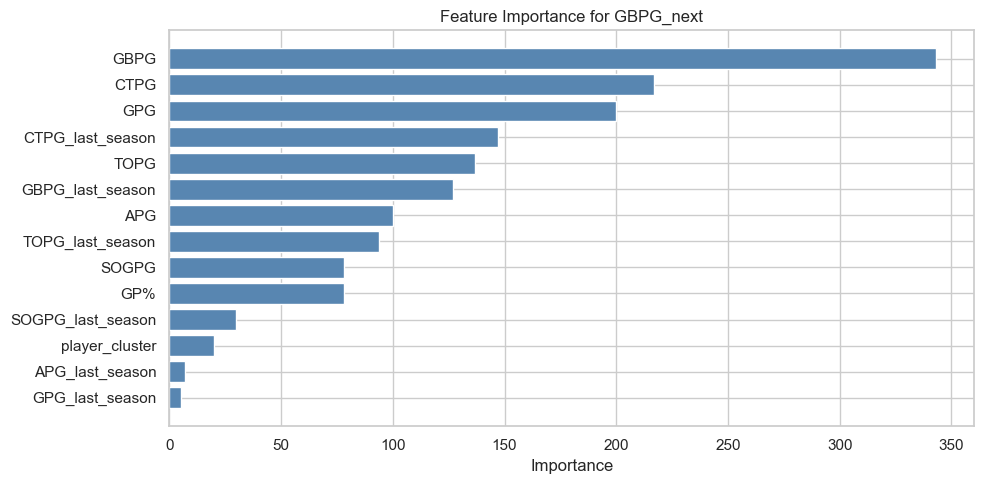

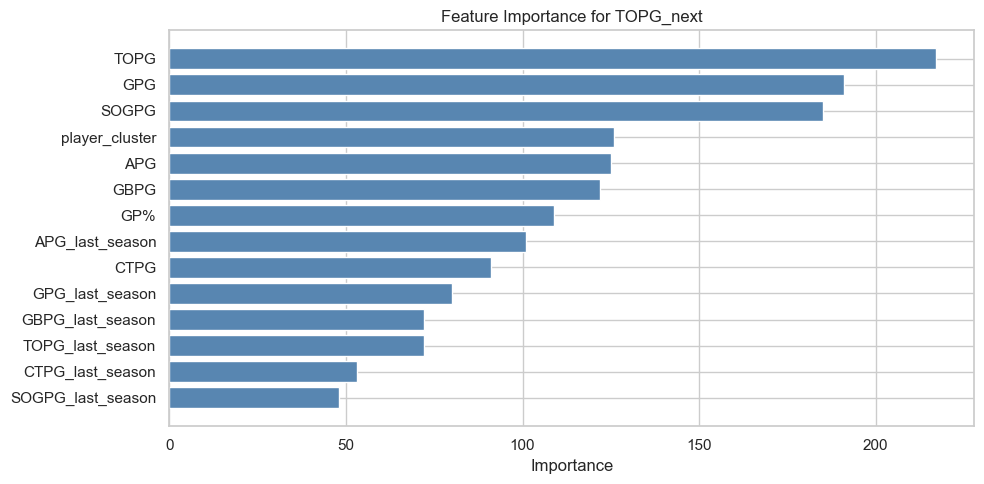

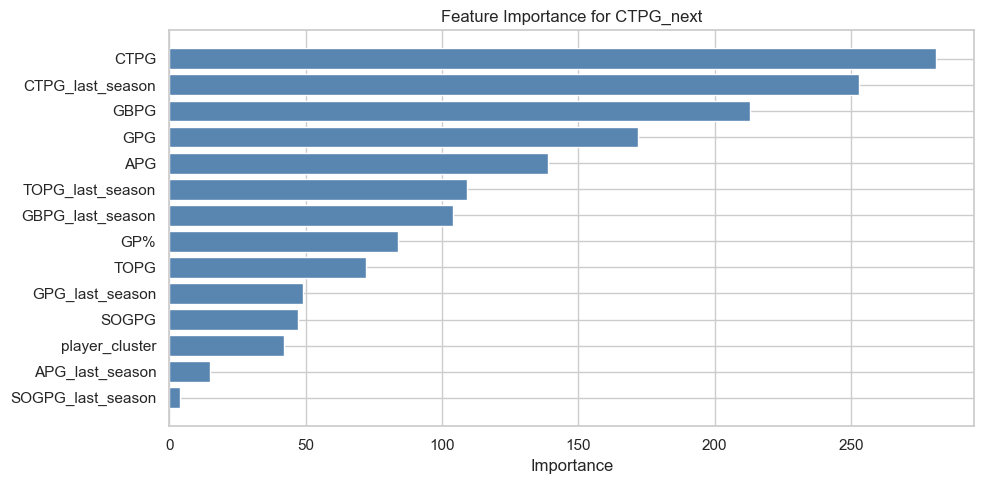

In [129]:
import matplotlib.pyplot as plt
import pandas as pd

# Loop through each target and its corresponding model
for i, target in enumerate(Y_train.columns):
    booster = model.estimators_[i].get_booster()
    importance_dict = booster.get_score(importance_type='weight')  # or try 'gain' or 'cover'

    # Convert to DataFrame for plotting
    importance_df = pd.DataFrame.from_dict(importance_dict, orient='index', columns=['Importance'])
    importance_df.index.name = 'Feature'
    importance_df.reset_index(inplace=True)

    # Sort by importance
    importance_df = importance_df.sort_values(by='Importance', ascending=False)

    # Plot
    plt.figure(figsize=(10, 5))
    plt.barh(importance_df['Feature'], importance_df['Importance'], color='#5886b1')
    plt.gca().invert_yaxis()
    plt.title(f'Feature Importance for {target}')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()



# Project Injured Players

In [29]:
injured_df = df_model[df_model['Injury'] == 1].copy()

In [30]:
# List of injury-related features to simulate as non-injured
injury_features = ['Injury', 'Injured_last_year', 'Total_injuries_to_date', 'Ever_injured']

counterfactual_df = injured_df.copy()
counterfactual_df[injury_features] = 0  # simulate no injury history

In [31]:
X_counterfactual = counterfactual_df[input_columns]
Y_counterfactual_pred = model.predict(X_counterfactual)

In [32]:
Y_actual = injured_df[target_columns]

comparison_df = injured_df[['Name', 'Year']].copy()
for i, stat in enumerate(target_columns):
    comparison_df[f'{stat}_actual'] = Y_actual.iloc[:, i]
    comparison_df[f'{stat}_pred_no_injury'] = Y_counterfactual_pred[:, i]
    comparison_df[f'{stat}_delta'] = comparison_df[f'{stat}_pred_no_injury'] - comparison_df[f'{stat}_actual']

In [33]:
summary_df = comparison_df.copy()
summary_df['total_delta'] = summary_df[[f'{stat}_delta' for stat in target_columns]].sum(axis=1)
summary_df = summary_df.sort_values(by='total_delta', ascending=False)


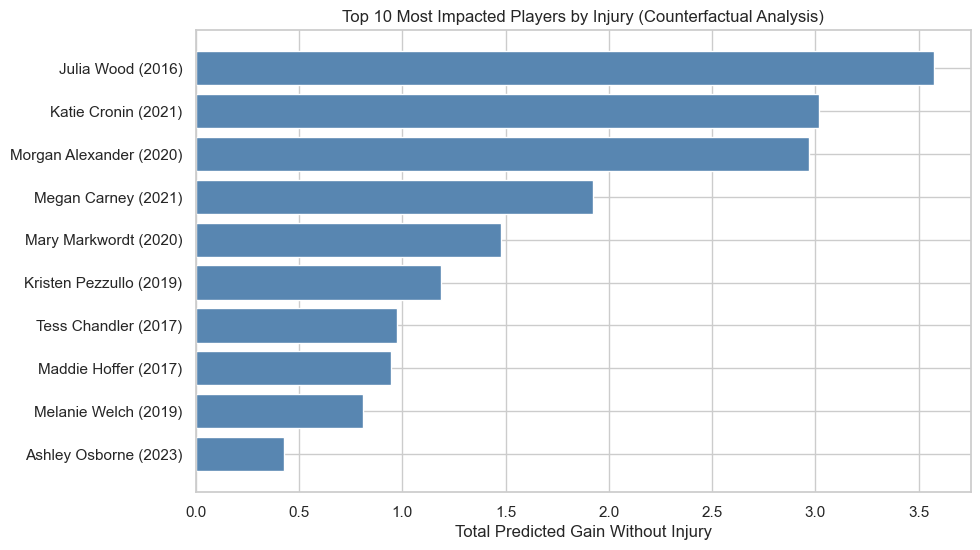

In [130]:
import matplotlib.pyplot as plt

top_10 = summary_df.head(10)
plt.figure(figsize=(10, 6))
plt.barh(top_10['Name'] + " (" + top_10['Year'].astype(str) + ")", top_10['total_delta'], color='#5886b1')
plt.xlabel("Total Predicted Gain Without Injury")
plt.title("Top 10 Most Impacted Players by Injury (Counterfactual Analysis)")
plt.gca().invert_yaxis()
plt.show()


In [52]:
player_name = "Morgan Alexander"
player_year = 2020

comparison_df[
    (comparison_df['Name'] == player_name) & (comparison_df['Year'] == player_year)
][[col for col in comparison_df.columns if 'delta' in col or 'actual' in col or 'pred' in col]]


,GPG_next_actual,GPG_next_pred_no_injury,GPG_next_delta,APG_next_actual,APG_next_pred_no_injury,APG_next_delta,SOGPG_next_actual,SOGPG_next_pred_no_injury,SOGPG_next_delta,GBPG_next_actual,GBPG_next_pred_no_injury,GBPG_next_delta,TOPG_next_actual,TOPG_next_pred_no_injury,TOPG_next_delta,CTPG_next_actual,CTPG_next_pred_no_injury,CTPG_next_delta
374,0.384615,1.258793,0.874178,0.0,0.440768,0.440768,1.0,2.264724,1.264724,0.230769,0.374577,0.143808,0.769231,1.022475,0.253244,0.153846,0.143792,-0.010054


In [64]:


# 1. Get all injured players and their full career data
injured_player_names = df_model[df_model['Injury'] == 1]['Name'].unique()
career_df = df_model[df_model['Name'].isin(injured_player_names)].copy()
career_df = career_df.sort_values(by=['Name', 'Year']).reset_index(drop=True)

# 2. Prepare storage for results
actual_rows = []
predicted_rows = []

# 3. Loop through each player's career
for name in injured_player_names:
    player_data = career_df[career_df['Name'] == name].copy()
    player_data = player_data.sort_values(by='Year').reset_index(drop=True)

    started_simulation = False
    for i in range(len(player_data)):
        row = player_data.iloc[i].copy()

        if not started_simulation:
            if row['Injury'] == 1:
                started_simulation = True
            else:
                # Not injured yet — just store actual row
                actual_rows.append(row.copy())
                predicted_rows.append(row.copy())
                continue

        # --- Simulate no-injury version of this season ---
        input_row = row[input_columns].copy()
        input_row['Injury'] = 0  # simulate healthy season
        input_row_df = pd.DataFrame([input_row.drop(labels='Injury')])
        pred = model.predict(input_row_df)[0]

        # Save actual and simulated values
        actual_rows.append(row.copy())

        pred_row = row.copy()
        for j, stat in enumerate(target_columns):
            pred_row[stat] = pred[j]  # overwrite target columns
        predicted_rows.append(pred_row)

        # Update lag features for next season if not last season
        if i + 1 < len(player_data):
            for j, stat in zip(target_columns, input_columns):
                stat_base = j.replace('_next', '')
                lag_col = f'{stat_base}_last_season'
                player_data.at[i + 1, lag_col] = pred_row[j]

# 4. Build output DataFrame
actual_df = pd.DataFrame(actual_rows)
predicted_df = pd.DataFrame(predicted_rows)

# Rename columns for clarity
for stat in target_columns:
    actual_df.rename(columns={stat: f'{stat}_actual'}, inplace=True)
    predicted_df.rename(columns={stat: f'{stat}_pred_no_injury'}, inplace=True)

# Merge into one DataFrame
career_comparison_df = actual_df[['Name', 'Year']].copy()
for stat in target_columns:
    career_comparison_df[f'{stat}_actual'] = actual_df[f'{stat}_actual']
    career_comparison_df[f'{stat}_pred_no_injury'] = predicted_df[f'{stat}_pred_no_injury']
    career_comparison_df[f'{stat}_delta'] = career_comparison_df[f'{stat}_pred_no_injury'] - career_comparison_df[f'{stat}_actual']


In [68]:
# Columns to sum
stat_base_names = ['GPG', 'APG', 'SOGPG', 'GBPG', 'TOPG', 'CTPG']

# Aggregate career totals across all seasons per player
career_totals = career_comparison_df.groupby('Name').agg({
    f'{stat}_next_actual': 'sum' for stat in stat_base_names
} | {
    f'{stat}_next_pred_no_injury': 'sum' for stat in stat_base_names
}).reset_index()

# Add delta columns for the difference between no-injury prediction and actual
for stat in stat_base_names:
    career_totals[f'{stat}_career_delta'] = (
        career_totals[f'{stat}_next_pred_no_injury'] - career_totals[f'{stat}_next_actual']
    )

career_totals.head()


,Name,GPG_next_actual,APG_next_actual,SOGPG_next_actual,GBPG_next_actual,TOPG_next_actual,CTPG_next_actual,GPG_next_pred_no_injury,APG_next_pred_no_injury,SOGPG_next_pred_no_injury,GBPG_next_pred_no_injury,TOPG_next_pred_no_injury,CTPG_next_pred_no_injury,GPG_career_delta,APG_career_delta,SOGPG_career_delta,GBPG_career_delta,TOPG_career_delta,CTPG_career_delta
0,Ashley Osborne,0.000000,0.000000,0.055556,4.895990,0.964495,2.324144,0.071594,0.043569,0.156289,5.021074,1.012027,2.362741,0.071594,0.043569,0.100733,0.125084,0.047533,0.038598
1,Bianca Chevarie,0.285714,0.047619,0.521645,6.030713,1.562360,4.012486,0.458406,0.146594,0.735588,5.298076,1.559359,3.675881,0.172692,0.098975,0.213943,-0.732637,-0.003001,-0.336605
2,Cassidy Weeks,6.192547,1.407867,10.142857,3.703934,3.298137,2.670807,5.561101,1.656854,8.244506,3.251212,3.508129,1.966703,-0.631445,0.248987,-1.898351,-0.452722,0.209992,-0.704105
3,Emily Hawryschuk,18.235902,4.343672,26.418860,4.124060,8.986216,1.408835,18.195499,4.169682,25.979128,4.061534,8.670270,1.515253,-0.040403,-0.173989,-0.439732,-0.062526,-0.315946,0.106418
4,Emma Tyrrell,10.281818,4.228571,14.786364,3.175974,5.346753,1.291991,9.777709,4.299852,14.122503,3.176223,5.857546,1.562989,-0.504109,0.071280,-0.663861,0.000249,0.510793,0.270997


C:\Users\Caden\AppData\Local\Temp\ipykernel_23784\3678817149.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_top_10, x=f'{stat}_career_delta', y='Name', palette=custom_palette)
C:\Users\Caden\AppData\Local\Temp\ipykernel_23784\3678817149.py:12: UserWarning: 
The palette list has fewer values (5) than needed (10) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(data=df_top_10, x=f'{stat}_career_delta', y='Name', palette=custom_palette)


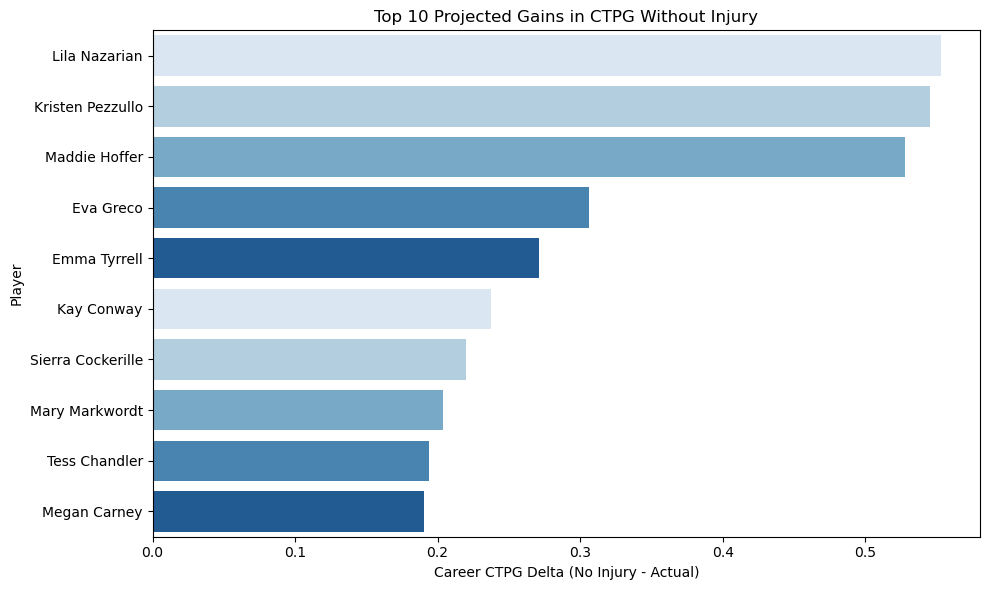

In [87]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the sum of career deltas for the stat
total_deltas = career_totals[f'{stat}_career_delta'].sum()

# Create a DataFrame for plotting (assuming you want to show top 10 players)
df_top_10 = career_totals[['Name', f'{stat}_career_delta']].sort_values(by=f'{stat}_career_delta', ascending=False).head(10)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=df_top_10, x=f'{stat}_career_delta', y='Name', palette=custom_palette)
plt.title(f"Top 10 Projected Gains in {stat.upper()} Without Injury")
plt.xlabel(f"Career {stat.upper()} Delta (No Injury - Actual)")
plt.ylabel("Player")
plt.tight_layout()
plt.show()


C:\Users\Caden\AppData\Local\Temp\ipykernel_23784\739242649.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_total_deltas, x='Total_Career_Delta', y='Name', palette= custom_palette)
C:\Users\Caden\AppData\Local\Temp\ipykernel_23784\739242649.py:15: UserWarning: 
The palette list has fewer values (5) than needed (24) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(data=df_total_deltas, x='Total_Career_Delta', y='Name', palette= custom_palette)


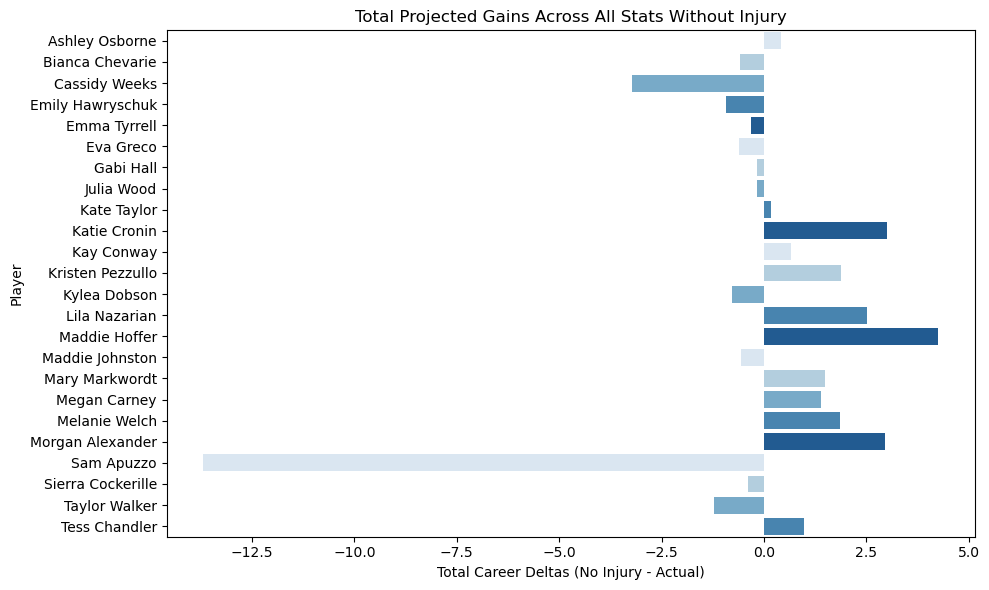

In [86]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filter columns that contain '_career_delta'
career_delta_columns = [col for col in career_totals.columns if '_career_delta' in col]

# Sum the values across all '_career_delta' columns for each player
career_totals['Total_Career_Delta'] = career_totals[career_delta_columns].sum(axis=1)

# Create a DataFrame with the player names and their total deltas
df_total_deltas = career_totals[['Name', 'Total_Career_Delta']]

# Plot the total career deltas
plt.figure(figsize=(10, 6))
sns.barplot(data=df_total_deltas, x='Total_Career_Delta', y='Name', palette= custom_palette)
plt.title("Total Projected Gains Across All Stats Without Injury")
plt.xlabel("Total Career Deltas (No Injury - Actual)")
plt.ylabel("Player")
plt.tight_layout()
plt.show()



C:\Users\Caden\AppData\Local\Temp\ipykernel_23784\372707272.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_deltas, x=f'{stat}_career_delta', y='Name', ax=axes[i], palette= custom_palette)
C:\Users\Caden\AppData\Local\Temp\ipykernel_23784\372707272.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_deltas, x=f'{stat}_career_delta', y='Name', ax=axes[i], palette= custom_palette)
C:\Users\Caden\AppData\Local\Temp\ipykernel_23784\372707272.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_deltas, x=f'{stat}_car

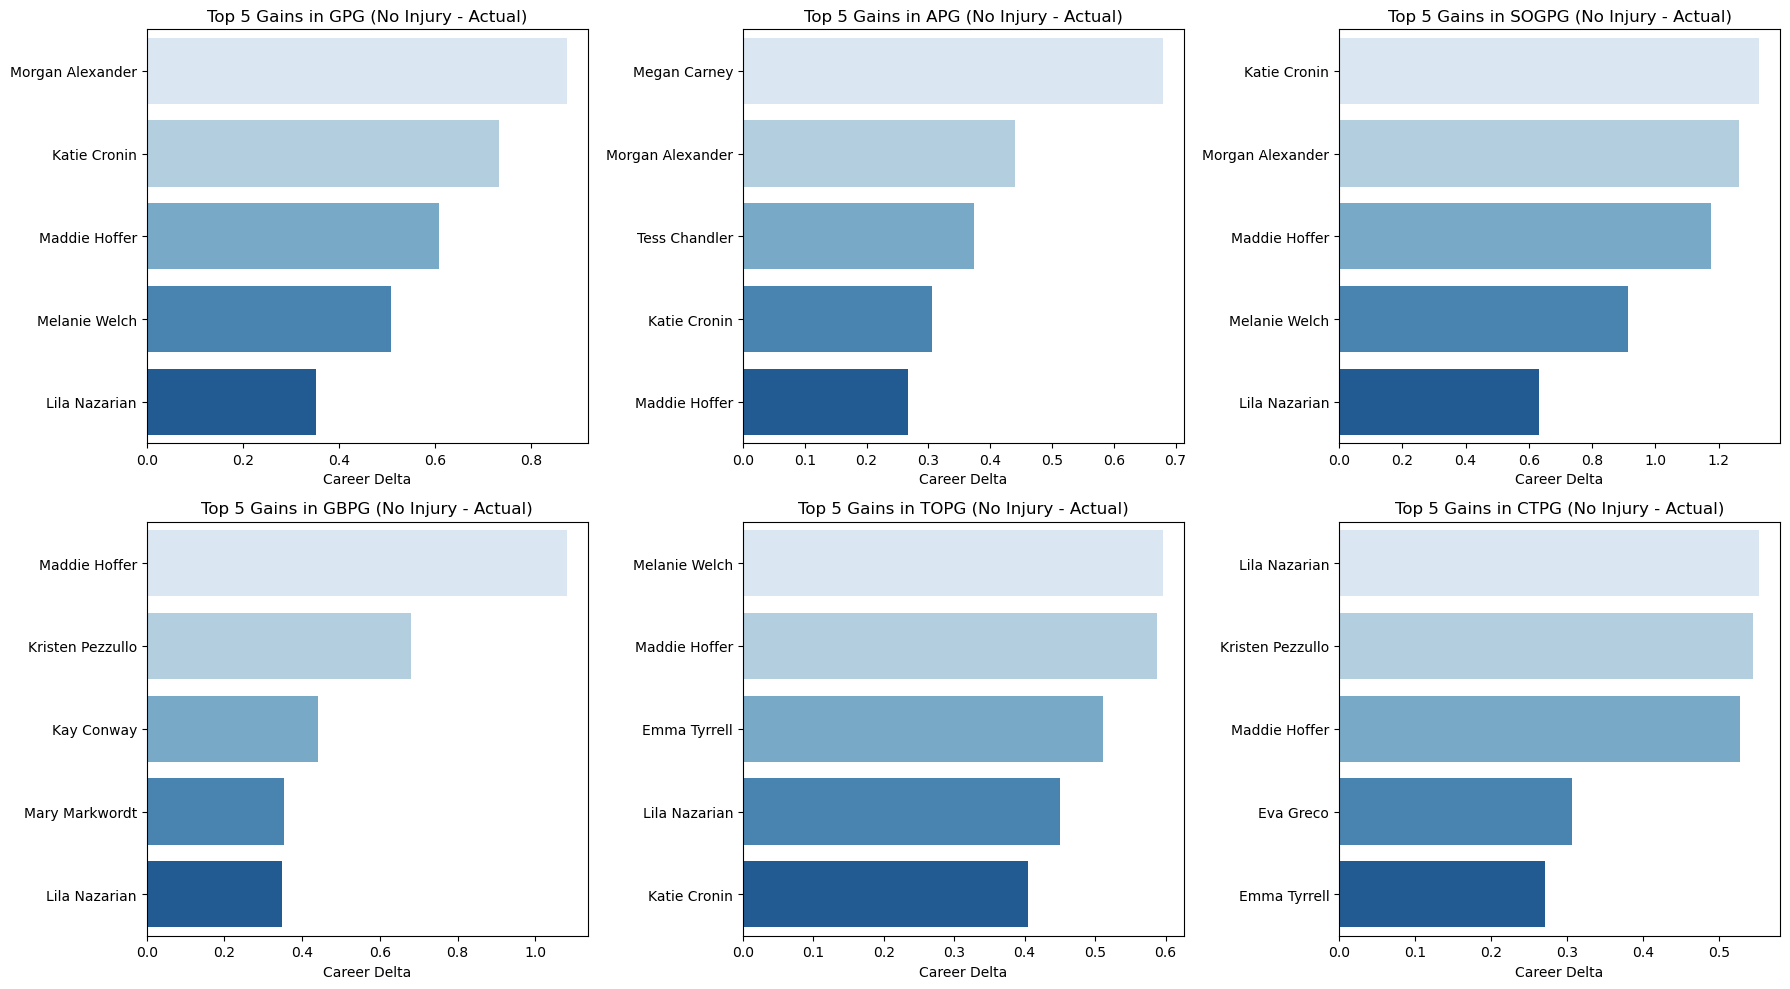

In [85]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

custom_palette = sns.color_palette("Blues", n_colors=5)


for i, stat in enumerate(stat_base_names):
    top_deltas = career_totals.sort_values(f'{stat}_career_delta', ascending=False).head(5)
    sns.barplot(data=top_deltas, x=f'{stat}_career_delta', y='Name', ax=axes[i], palette= custom_palette)
    axes[i].set_title(f"Top 5 Gains in {stat} (No Injury - Actual)")
    axes[i].set_xlabel("Career Delta")
    axes[i].set_ylabel("")

plt.tight_layout()
plt.show()
